In [ ]:
# Neonatal Seizure Forecasting Pipeline

This notebook implements a complete pipeline for neonatal seizure forecasting using:
1. Contrastive learning pretraining (SimCLR approach)
2. Spiking Neural Network fine-tuning

The pipeline consists of the following steps:
- Loading EEG data and annotations
- Preprocessing EEG data
- SimCLR-style contrastive pretraining
- Converting ANN to Spiking ResNet
- Fine-tuning for seizure forecasting
- Evaluation and visualization


In [ ]:
## 1. Setup and Required Libraries


In [ ]:
## 1. Setup and Required Libraries


In [ ]:
## 1. Setup and Required Libraries


In [185]:
# Install required libraries
!pip install -q snntorch
!pip install -q pyEDFlib
!pip install -q numpy pandas matplotlib scikit-learn torch torchvision tqdm


In [186]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm  # Use regular tqdm instead of tqdm.notebook

# Data processing
import pyedflib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, auc

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# snnTorch
import snntorch as snn
from snntorch import surrogate

# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED) if torch.cuda.is_available() else None

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [ ]:
## 2. Data Loading and Preprocessing


In [187]:
# Define paths
DATA_DIR = 'dataset'
EEG_DIR = DATA_DIR
ANNOTATIONS_FILE = os.path.join(DATA_DIR, 'annotations_2017_A_fixed.csv')  # Using the available annotation file
CLINICAL_INFO_FILE = os.path.join(DATA_DIR, 'clinical_information.csv')


In [188]:
# Function to load annotations
def load_annotations(annotations_file):
    """
    Load seizure annotations from CSV file
    """
    try:
        annotations_df = pd.read_csv(annotations_file)
        print(f"Annotations loaded successfully. Shape: {annotations_df.shape}")
        print(f"Column names: {annotations_df.columns.tolist()}")
        return annotations_df
    except Exception as e:
        print(f"Error loading annotations: {str(e)}")
        # Try to load with different delimiter or encoding
        try:
            annotations_df = pd.read_csv(annotations_file, delimiter=',', encoding='utf-8')
            print(f"Annotations loaded with custom params. Shape: {annotations_df.shape}")
            return annotations_df
        except Exception as e2:
            print(f"Error with alternative loading method: {str(e2)}")
            return None


In [189]:
# Function to load clinical information
def load_clinical_info(clinical_info_file):
    """
    Load clinical information from CSV file
    """
    try:
        clinical_info_df = pd.read_csv(clinical_info_file)
        print(f"Clinical info loaded successfully. Shape: {clinical_info_df.shape}")
        return clinical_info_df
    except Exception as e:
        print(f"Error loading clinical info: {str(e)}")
        return None


In [190]:
# Load annotations and clinical info
annotations_df = load_annotations(ANNOTATIONS_FILE)
clinical_info_df = load_clinical_info(CLINICAL_INFO_FILE)


Annotations loaded successfully. Shape: (15416, 79)
Column names: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79']
Clinical info loaded successfully. Shape: (79, 12)


In [191]:
# Display first few rows of annotations if available
if annotations_df is not None:
    print("\nFirst few rows of annotations:")
    print(annotations_df.head())
    
# Display first few rows of clinical info if available
if clinical_info_df is not None:
    print("\nFirst few rows of clinical information:")
    print(clinical_info_df.head())



First few rows of annotations:
     1    2    3    4    5    6    7    8    9   10  ...   70   71   72   73  \
0  0.0  0.0  0.0  0.0  1.0  0.0  1.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
1  0.0  0.0  0.0  0.0  1.0  0.0  1.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
2  0.0  0.0  0.0  0.0  1.0  0.0  1.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
3  0.0  0.0  0.0  0.0  1.0  0.0  1.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
4  0.0  0.0  0.0  0.0  1.0  0.0  1.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   

    74   75   76   77   78   79  
0  0.0  0.0  0.0  0.0  0.0  0.0  
1  0.0  0.0  0.0  0.0  0.0  0.0  
2  0.0  0.0  0.0  0.0  0.0  0.0  
3  0.0  0.0  0.0  0.0  0.0  0.0  
4  0.0  0.0  0.0  0.0  0.0  0.0  

[5 rows x 79 columns]

First few rows of clinical information:
   ID EEG file Gender           BW (g) GA (weeks) EEG to PMA (weeks)  \
0   1     eeg1      f  less than 2500g   37 to 38           37 to 38   
1   2     eeg2      m  less than 2500g   35 to 36           37 to 38   
2  

In [192]:
# Function to load EEG from EDF file
def load_eeg_file(edf_file):
    """
    Load EEG data from an EDF file
    """
    try:
        f = pyedflib.EdfReader(edf_file)
        n = f.signals_in_file
        signal_labels = f.getSignalLabels()
        
        sigbufs = np.zeros((n, f.getNSamples()[0]))
        for i in range(n):
            sigbufs[i, :] = f.readSignal(i)
            
        # Get sampling frequency
        fs = f.getSampleFrequency(0)
        f.close()
        
        return sigbufs, signal_labels, fs
    except Exception as e:
        print(f"Error loading EEG file {edf_file}: {str(e)}")
        return None, None, None


In [193]:
# Function to get all EEG files
def get_eeg_files(eeg_dir):
    """
    Get all EEG files from the directory
    """
    eeg_files = [os.path.join(eeg_dir, f) for f in os.listdir(eeg_dir) if f.endswith('.edf')]
    print(f"Found {len(eeg_files)} EEG files")
    return eeg_files


Found 79 EEG files

Loading sample EEG file: eeg1.edf
Signal shape: (21, 1790208)
Signal labels: ['EEG Fp1-REF', 'EEG Fp2-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG O1-REF', 'EEG O2-REF', 'EEG F7-REF', 'EEG F8-REF', 'EEG T3-REF', 'EEG T4-REF', 'EEG T5-REF', 'EEG T6-REF', 'EEG Fz-REF', 'EEG Cz-REF', 'EEG Pz-REF', 'ECG EKG-REF', 'Resp Effort-REF']
Sampling frequency: 256.0 Hz


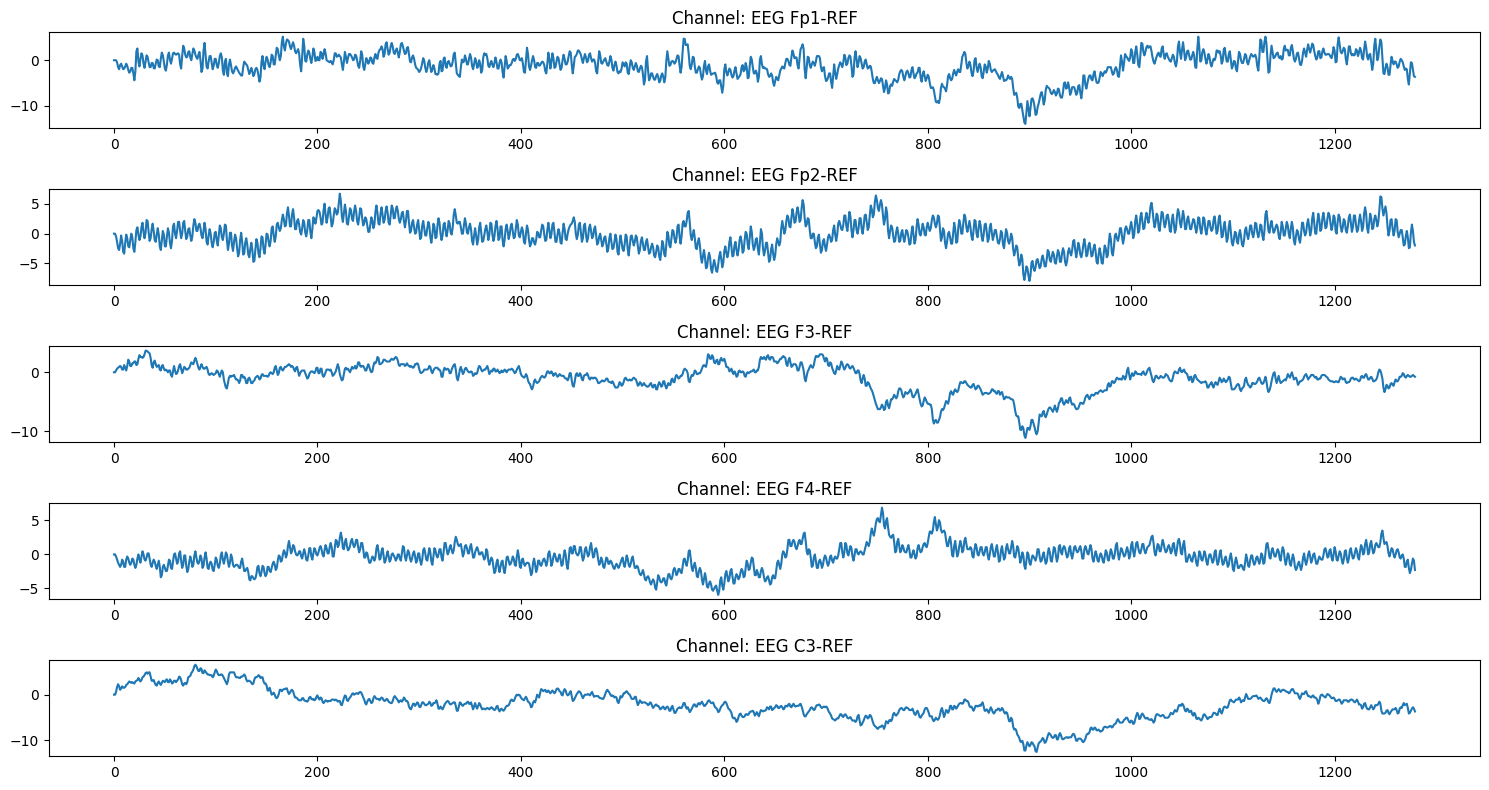

In [194]:
# Get list of EEG files
eeg_files = get_eeg_files(EEG_DIR)

# Test load of one EEG file to check structure
if eeg_files:
    print(f"\nLoading sample EEG file: {os.path.basename(eeg_files[0])}")
    sigbufs, signal_labels, fs = load_eeg_file(eeg_files[0])
    if sigbufs is not None:
        print(f"Signal shape: {sigbufs.shape}")
        print(f"Signal labels: {signal_labels}")
        print(f"Sampling frequency: {fs} Hz")
        
        # Plot first few seconds of first few channels
        plt.figure(figsize=(15, 8))
        seconds_to_plot = 5
        channels_to_plot = min(5, sigbufs.shape[0])
        
        for i in range(channels_to_plot):
            plt.subplot(channels_to_plot, 1, i+1)
            plt.plot(sigbufs[i, :int(seconds_to_plot * fs)])
            plt.title(f"Channel: {signal_labels[i]}")
        
        plt.tight_layout()
        plt.show()


In [ ]:
## 3. EEG Preprocessing and Segment Extraction


In [195]:
# Define constants for segmentation
WINDOW_SIZE_SEC = 10  # 10-second windows for EEG segments
PRE_ICTAL_WINDOW = 4 * 60  # 4 minutes (in seconds) before seizure onset
INTER_ICTAL_MIN_DIST = 5 * 60  # At least 5 minutes (in seconds) away from any seizure


In [196]:
# Function to extract segments from EEG data
def extract_segments(eeg_data, fs, window_size_sec=WINDOW_SIZE_SEC, overlap=0.5):
    """
    Extract segments from EEG data using sliding window
    
    Args:
        eeg_data: EEG data array [channels, samples]
        fs: Sampling frequency
        window_size_sec: Size of window in seconds
        overlap: Overlap between consecutive windows (0 to 1)
        
    Returns:
        List of segments, each of shape [channels, samples_in_window]
    """
    n_channels, n_samples = eeg_data.shape
    samples_per_window = int(window_size_sec * fs)
    step_size = int(samples_per_window * (1 - overlap))
    
    segments = []
    for start in range(0, n_samples - samples_per_window + 1, step_size):
        end = start + samples_per_window
        segment = eeg_data[:, start:end]
        segments.append(segment)
    
    return segments


In [197]:
# Function to normalize EEG data
def normalize_segment(segment, per_channel=True):
    """
    Normalize EEG segment
    
    Args:
        segment: EEG segment [channels, samples]
        per_channel: If True, normalize each channel independently
        
    Returns:
        Normalized EEG segment
    """
    if per_channel:
        # Normalize each channel independently
        for i in range(segment.shape[0]):
            # Skip normalization if channel is flat or near-flat
            if np.std(segment[i]) > 1e-6:  # Avoid division by near-zero std
                segment[i] = (segment[i] - np.mean(segment[i])) / np.std(segment[i])
    else:
        # Global normalization
        if np.std(segment) > 1e-6:
            segment = (segment - np.mean(segment)) / np.std(segment)
    
    return segment


In [198]:
# Parse annotations to identify seizure time points
def parse_seizure_annotations(annotations_df, eeg_files):
    """
    Parse annotations to identify seizure time points for each EEG file
    
    Returns:
        Dictionary mapping EEG file paths to list of seizure onset times (in seconds)
    """
    seizure_info = {}
    
    # Initialize empty lists for all EEG files
    for eeg_file in eeg_files:
        seizure_info[eeg_file] = []
    
    # Process annotations dataframe
    # We assume that annotations_df has columns 1-79 corresponding to EEG file IDs
    # and values indicate seizure events (1.0) or no seizure (0.0)
    if annotations_df is not None:
        # Iterate through each row in annotations (representing time points)
        for index, row in annotations_df.iterrows():
            # Each column represents a patient/file
            for col_idx in range(1, 80):  # Columns 1 to 79
                col_name = str(col_idx)
                if col_name in row.index and row[col_name] == 1.0:
                    # This indicates a seizure for this file at this time point
                    # Find the corresponding EEG file
                    eeg_filename = f"eeg{col_idx}.edf"
                    eeg_file_path = next((f for f in eeg_files if os.path.basename(f) == eeg_filename), None)
                    
                    if eeg_file_path:
                        # For simplicity, we'll use the row index as the seizure time (in seconds)
                        # In a real scenario, you might have actual timestamps
                        seizure_time = index * 30  # Using row index * 30 as a proxy for time in seconds (assuming 30s epochs)
                        seizure_info[eeg_file_path].append(seizure_time)
    
    # Print summary
    total_seizures = sum(len(times) for times in seizure_info.values())
    files_with_seizures = sum(1 for times in seizure_info.values() if len(times) > 0)
    print(f"Parsed seizure information for {len(seizure_info)} EEG files")
    print(f"Found {total_seizures} seizure events across {files_with_seizures} files")
    
    return seizure_info


In [199]:
# Function to identify preictal and interictal segments
def classify_segments(eeg_file, segments, seizure_times, fs, window_size_sec=WINDOW_SIZE_SEC, 
                     preictal_window=PRE_ICTAL_WINDOW, interictal_min_dist=INTER_ICTAL_MIN_DIST):
    """
    Classify segments as preictal or interictal
    
    Args:
        eeg_file: Path to EEG file
        segments: List of EEG segments
        seizure_times: List of seizure onset times (in seconds) for this file
        fs: Sampling frequency
        window_size_sec: Size of segment window in seconds
        preictal_window: Time before seizure to label as preictal (seconds)
        interictal_min_dist: Minimum distance from seizures to label as interictal (seconds)
        
    Returns:
        preictal_segments: List of preictal segments
        interictal_segments: List of interictal segments
    """
    preictal_segments = []
    interictal_segments = []
    unlabeled_segments = []
    
    step_size = window_size_sec // 2  # Assuming 50% overlap
    
    # Go through each segment and classify
    for i, segment in enumerate(segments):
        segment_start_sec = i * step_size
        segment_end_sec = segment_start_sec + window_size_sec
        
        # Check if segment is preictal (4 min before seizure)
        is_preictal = False
        for seizure_time in seizure_times:
            if (seizure_time - preictal_window) <= segment_end_sec <= seizure_time:
                preictal_segments.append(segment)
                is_preictal = True
                break
                
        if is_preictal:
            continue
            
        # Check if segment is interictal (≥5 min away from any seizure)
        is_interictal = True
        for seizure_time in seizure_times:
            dist_before = segment_end_sec - seizure_time
            dist_after = seizure_time - segment_start_sec
            
            # If segment is too close to any seizure, it's not interictal
            if -interictal_min_dist < dist_before < interictal_min_dist or \
               -interictal_min_dist < dist_after < interictal_min_dist:
                is_interictal = False
                break
                
        if is_interictal:
            interictal_segments.append(segment)
        else:
            unlabeled_segments.append(segment)
            
    print(f"File {os.path.basename(eeg_file)}: Found {len(preictal_segments)} preictal, "
          f"{len(interictal_segments)} interictal, {len(unlabeled_segments)} unlabeled segments")
    
    return preictal_segments, interictal_segments


In [200]:
# Process all EEG files to extract labeled segments
def process_eeg_data(eeg_files, seizure_info, max_files=None, debug=False):
    """
    Process all EEG files to extract labeled segments
    
    Args:
        eeg_files: List of EEG file paths
        seizure_info: Dictionary mapping EEG file paths to seizure onset times
        max_files: Maximum number of files to process (for debugging)
        debug: If True, print debug information
        
    Returns:
        all_preictal_segments: List of preictal segments
        all_interictal_segments: List of interictal segments
    """
    all_preictal_segments = []
    all_interictal_segments = []
    
    if max_files:
        eeg_files = eeg_files[:max_files]
    
    total_files = len(eeg_files)
    print(f"Processing {total_files} EEG files...")
    
    # Manually track progress instead of using tqdm
    for i, eeg_file in enumerate(eeg_files):
        # Report progress every ~10% of files
        if i % max(1, total_files // 10) == 0 or i == total_files - 1:
            print(f"Processing file {i+1}/{total_files} ({(i+1)/total_files*100:.1f}%)")
        
        if debug:
            print(f"\nProcessing {os.path.basename(eeg_file)}")
        
        # Load EEG data
        sigbufs, signal_labels, fs = load_eeg_file(eeg_file)
        if sigbufs is None:
            print(f"Skipping {os.path.basename(eeg_file)} due to loading error")
            continue
            
        # Extract segments
        segments = extract_segments(sigbufs, fs)
        
        # Normalize segments
        normalized_segments = [normalize_segment(segment.copy()) for segment in segments]
        
        # Get seizure times for this file
        seizure_times = seizure_info.get(eeg_file, [])
        
        # Classify segments
        preictal_segments, interictal_segments = classify_segments(
            eeg_file, normalized_segments, seizure_times, fs)
        
        all_preictal_segments.extend(preictal_segments)
        all_interictal_segments.extend(interictal_segments)
    
    print(f"\nTotal segments extracted: {len(all_preictal_segments)} preictal, "
          f"{len(all_interictal_segments)} interictal")
    
    return all_preictal_segments, all_interictal_segments


In [201]:
# Parse seizure annotations and process EEG data
seizure_info = parse_seizure_annotations(annotations_df, eeg_files)

# Process all files in the dataset
print(f"Processing all {len(eeg_files)} EEG files...")
all_preictal_segments, all_interictal_segments = process_eeg_data(eeg_files, seizure_info, max_files=None)

# Convert segments to numpy arrays
if all_preictal_segments and all_interictal_segments:
    # Stack numpy arrays
    X_preictal = np.stack(all_preictal_segments)
    X_interictal = np.stack(all_interictal_segments)
    
    print(f"Preictal data shape: {X_preictal.shape}")
    print(f"Interictal data shape: {X_interictal.shape}")
else:
    print("No segments were extracted. Check the seizure annotations parsing and segment extraction.")
    # We want to work with real data, so we'll raise an error rather than create dummy data
    raise ValueError("No preictal or interictal segments were found. Please check the annotations and data processing.")


Parsed seizure information for 79 EEG files
Found 47942 seizure events across 46 files
Processing all 79 EEG files...
Processing 79 EEG files...
Processing file 1/79 (1.3%)
File eeg1.edf: Found 151 preictal, 1174 interictal, 72 unlabeled segments
File eeg10.edf: Found 0 preictal, 1084 interictal, 0 unlabeled segments
File eeg11.edf: Found 0 preictal, 1496 interictal, 0 unlabeled segments
File eeg12.edf: Found 0 preictal, 892 interictal, 0 unlabeled segments
File eeg13.edf: Found 1745 preictal, 1276 interictal, 61 unlabeled segments
File eeg14.edf: Found 0 preictal, 744 interictal, 0 unlabeled segments
File eeg15.edf: Found 131 preictal, 1186 interictal, 61 unlabeled segments
Processing file 8/79 (10.1%)
File eeg16.edf: Found 313 preictal, 802 interictal, 72 unlabeled segments
File eeg17.edf: Found 0 preictal, 1097 interictal, 0 unlabeled segments
File eeg18.edf: Found 0 preictal, 729 interictal, 0 unlabeled segments
File eeg19.edf: Found 0 preictal, 1800 interictal, 0 unlabeled segment

In [ ]:
## 1. Setup and Required Libraries


In [202]:
# Define data augmentation techniques for EEG data
class EEGAugmentations:
    @staticmethod
    def add_gaussian_noise(eeg_segment, std_factor=0.1):
        """Add Gaussian noise to EEG segment"""
        noise = np.random.normal(0, std_factor * np.std(eeg_segment), eeg_segment.shape)
        return eeg_segment + noise
    
    @staticmethod
    def random_dropout(eeg_segment, dropout_prob=0.1):
        """Randomly drop values in EEG segment"""
        mask = np.random.binomial(1, 1 - dropout_prob, eeg_segment.shape)
        return eeg_segment * mask
    
    @staticmethod
    def temporal_shift(eeg_segment, max_shift_factor=0.1):
        """Apply temporal shift to EEG segment"""
        # Calculate max shift in samples
        n_samples = eeg_segment.shape[1]
        max_shift = int(n_samples * max_shift_factor)
        
        # Choose random shift amount
        shift = np.random.randint(-max_shift, max_shift + 1)
        
        # Apply shift
        shifted = np.zeros_like(eeg_segment)
        
        if shift > 0:
            shifted[:, shift:] = eeg_segment[:, :-shift]
        elif shift < 0:
            shifted[:, :shift] = eeg_segment[:, -shift:]
        else:
            shifted = eeg_segment.copy()
            
        return shifted
    
    @staticmethod
    def channel_dropout(eeg_segment, dropout_prob=0.1):
        """Randomly drop channels in EEG segment"""
        mask = np.random.binomial(1, 1 - dropout_prob, (eeg_segment.shape[0], 1))
        return eeg_segment * mask
    
    @staticmethod
    def random_amplitude_scale(eeg_segment, scale_range=(0.7, 1.3)):
        """Randomly scale amplitude of EEG segment"""
        scale = np.random.uniform(scale_range[0], scale_range[1])
        return eeg_segment * scale


In [203]:
# Function to apply random augmentations
def apply_random_augmentations(eeg_segment):
    """Apply a random combination of augmentations to an EEG segment"""
    # Copy the segment to avoid modifying the original
    augmented = eeg_segment.copy()
    
    # List of available augmentations with probability of applying each
    augmentations = [
        (EEGAugmentations.add_gaussian_noise, 0.7),
        (EEGAugmentations.random_dropout, 0.5),
        (EEGAugmentations.temporal_shift, 0.5),
        (EEGAugmentations.channel_dropout, 0.3),
        (EEGAugmentations.random_amplitude_scale, 0.7)
    ]
    
    # Apply each augmentation with its probability
    for aug_func, prob in augmentations:
        if np.random.random() < prob:
            augmented = aug_func(augmented)
            
    return augmented


In [204]:
# Create a PyTorch dataset for SimCLR contrastive learning
class SimCLRDataset(Dataset):
    def __init__(self, eeg_segments):
        self.eeg_segments = eeg_segments
        
    def __len__(self):
        return len(self.eeg_segments)
    
    def __getitem__(self, idx):
        eeg_segment = self.eeg_segments[idx]
        
        # Create two augmented views of the segment
        view1 = apply_random_augmentations(eeg_segment)
        view2 = apply_random_augmentations(eeg_segment)
        
        # Convert to torch tensors (float32)
        view1 = torch.tensor(view1, dtype=torch.float32)
        view2 = torch.tensor(view2, dtype=torch.float32)
        
        return view1, view2


In [205]:
# Define the CNN encoder
class CNNEncoder(nn.Module):
    def __init__(self, in_channels, embedding_dim=128):
        super(CNNEncoder, self).__init__()
        
        # Configuration
        self.in_channels = in_channels
        self.embedding_dim = embedding_dim
        
        # Initial convolution block
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )
        
        # ResNet-like blocks
        self.conv2 = self._make_residual_block(32, 64, stride=2)
        self.conv3 = self._make_residual_block(64, 128, stride=2)
        self.conv4 = self._make_residual_block(128, 256, stride=2)
        
        # Global average pooling
        self.gap = nn.AdaptiveAvgPool1d(1)
        
        # Projection head
        self.fc = nn.Linear(256, embedding_dim)
        
    def _make_residual_block(self, in_channels, out_channels, stride=1):
        """Create a ResNet-like block"""
        layers = []
        
        # Downsample + input projection
        downsample = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
            nn.BatchNorm1d(out_channels)
        )
        
        # Add residual block
        layers.append(ResidualBlock(in_channels, out_channels, stride, downsample))
        
        # Add another residual block without downsampling
        layers.append(ResidualBlock(out_channels, out_channels))
        
        return nn.Sequential(*layers)
        
    def forward(self, x):
        # Expected input shape: [batch_size, n_channels, signal_length]
        
        # Apply convolution blocks
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        
        # Global average pooling
        x = self.gap(x)
        x = x.view(x.size(0), -1)  # Flatten
        
        # Projection
        x = self.fc(x)
        
        return x


In [206]:
# Define a residual block
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, 
                              stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, 
                              stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        self.downsample = downsample
        
    def forward(self, x):
        identity = x
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        if self.downsample is not None:
            identity = self.downsample(x)
            
        out += identity
        out = self.relu(out)
        
        return out


In [207]:
# Define the SimCLR model with projection head
class SimCLR(nn.Module):
    def __init__(self, encoder, projection_dim=128):
        super(SimCLR, self).__init__()
        
        self.encoder = encoder
        
        # Projection head (MLP)
        self.projection = nn.Sequential(
            nn.Linear(encoder.embedding_dim, encoder.embedding_dim),
            nn.ReLU(),
            nn.Linear(encoder.embedding_dim, projection_dim)
        )
        
    def forward(self, x):
        # Get representation from encoder
        h = self.encoder(x)
        
        # Project to contrastive space
        z = self.projection(h)
        
        # Normalize projection
        z = F.normalize(z, dim=-1)
        
        return h, z


In [208]:
# NT-Xent loss function (Normalized Temperature-scaled Cross Entropy Loss)
class NTXentLoss(nn.Module):
    def __init__(self, batch_size, temperature=0.5):
        super(NTXentLoss, self).__init__()
        self.batch_size = batch_size
        self.temperature = temperature
        self.criterion = nn.CrossEntropyLoss(reduction="sum")
        self.similarity_f = nn.CosineSimilarity(dim=2)
        
        # Create mask for positive pairs
        self.mask = self._get_mask().to(device)
        
    def _get_mask(self):
        mask = torch.zeros(2 * self.batch_size, 2 * self.batch_size, dtype=bool)
        
        # Each example has one positive pair (the other augmented version)
        for i in range(self.batch_size):
            mask[i, self.batch_size + i] = 1
            mask[self.batch_size + i, i] = 1
            
        return mask
        
    def forward(self, z_i, z_j):
        # Concatenate the representations from the two views
        representations = torch.cat([z_i, z_j], dim=0)
        
        # Compute similarity matrix
        similarity_matrix = self.similarity_f(representations.unsqueeze(1), representations.unsqueeze(0))
        
        # Remove diagonal elements (self-similarity)
        sim_ij = torch.diag(similarity_matrix, self.batch_size)
        sim_ji = torch.diag(similarity_matrix, -self.batch_size)
        positives = torch.cat([sim_ij, sim_ji], dim=0)
        
        # Remove the positive pairs from the similarity matrix
        mask = self.mask.clone()
        mask[torch.eye(2 * self.batch_size, dtype=bool)] = 0  # Remove the diagonal
        
        negatives = similarity_matrix[~mask].reshape(2 * self.batch_size, -1)
        
        # Compute logits
        logits = torch.cat([positives.unsqueeze(1), negatives], dim=1) / self.temperature
        
        # Labels: positives are the first element of each row
        labels = torch.zeros(2 * self.batch_size, dtype=torch.long).to(device)
        
        loss = self.criterion(logits, labels)
        return loss / (2 * self.batch_size)


In [209]:
# Prepare data for SimCLR pretraining (use only interictal segments)
# We'll use interictal segments for unsupervised pretraining
simclr_train_data = SimCLRDataset(X_interictal)

# Define training parameters
BATCH_SIZE = 32
NUM_EPOCHS = 100  # Full number of epochs for actual training
EMBEDDING_DIM = 128
PROJECTION_DIM = 64
LEARNING_RATE = 1e-4

# Create data loaders
train_loader = DataLoader(
    simclr_train_data, 
    batch_size=BATCH_SIZE,
    shuffle=True, 
    num_workers=0,
    drop_last=True  # Drop the last batch if it's smaller than batch_size
)

# Instantiate the model
n_channels = X_interictal.shape[1]  # Number of EEG channels
encoder = CNNEncoder(in_channels=n_channels, embedding_dim=EMBEDDING_DIM)
simclr_model = SimCLR(encoder=encoder, projection_dim=PROJECTION_DIM)
simclr_model = simclr_model.to(device)

# Define optimizer
optimizer = optim.Adam(simclr_model.parameters(), lr=LEARNING_RATE)

# Define loss function
criterion = NTXentLoss(batch_size=BATCH_SIZE)


In [210]:
# SimCLR training function
def train_simclr(model, train_loader, criterion, optimizer, epochs, device):
    """Train the SimCLR model"""
    model.train()
    losses = []
    
    for epoch in range(epochs):
        running_loss = 0.0
        
        # Progress bar for each epoch
        pbar = tqdm(enumerate(train_loader), 
                    total=len(train_loader),
                    desc=f"Epoch {epoch+1}/{epochs}")
        
        for i, (x_i, x_j) in pbar:
            # Move data to device
            x_i = x_i.to(device)
            x_j = x_j.to(device)
            
            # Forward pass
            _, z_i = model(x_i)
            _, z_j = model(x_j)
            
            # Compute loss
            loss = criterion(z_i, z_j)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Update running loss
            running_loss += loss.item()
            
            # Update progress bar
            pbar.set_postfix({"Loss": loss.item()})
            
        # Compute average loss for the epoch
        epoch_loss = running_loss / len(train_loader)
        losses.append(epoch_loss)
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.6f}")
    
    return losses


Starting SimCLR pretraining...


Epoch 1/100: 100%|██████████| 2043/2043 [12:09<00:00,  2.80it/s, Loss=2.5] 


Epoch 1/100, Loss: 2.544875


Epoch 2/100: 100%|██████████| 2043/2043 [13:53<00:00,  2.45it/s, Loss=2.43]


Epoch 2/100, Loss: 2.445295


...

Epoch 98/100, Loss: 2.330990


Epoch 99/100: 100%|██████████| 2043/2043 [11:29<00:00,  2.96it/s, Loss=2.33]


Epoch 99/100, Loss: 2.330751


Epoch 100/100: 100%|██████████| 2043/2043 [09:32<00:00,  3.57it/s, Loss=2.32]


Epoch 100/100, Loss: 2.330631


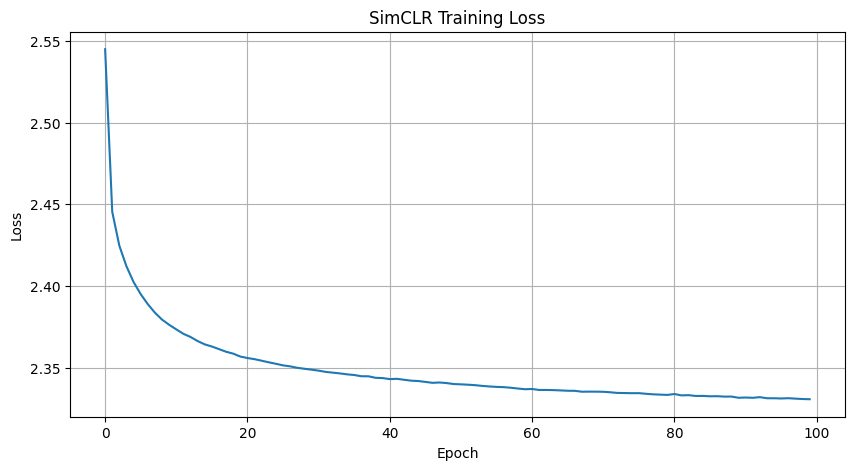

SimCLR model trained and saved to 'simclr_pretrained.pt'
Encoder saved to 'encoder_pretrained.pt'


In [211]:
# Run actual SimCLR pretraining on GPU
print("Starting SimCLR pretraining...")
losses = train_simclr(
    model=simclr_model,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=NUM_EPOCHS,
    device=device
)

# Plot the loss curve
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title('SimCLR Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Save the pretrained model
os.makedirs('pretrained_models', exist_ok=True)
torch.save(simclr_model.state_dict(), 'pretrained_models/simclr_pretrained.pt')
torch.save(encoder.state_dict(), 'pretrained_models/encoder_pretrained.pt')
print("SimCLR model trained and saved to 'simclr_pretrained.pt'")
print("Encoder saved to 'encoder_pretrained.pt'")


In [240]:
import numpy as np
import os
X_preictal = np.stack(all_preictal_segments).astype(np.float32)
print(f"Created X_preictal with shape: {X_preictal.shape}, dtype: {X_preictal.dtype}")
os.makedirs('data', exist_ok=True)
np.save('data/X_preictal.npy', X_preictal)
X_interictal = np.stack(all_interictal_segments).astype(np.float32)
print(f"Created X_interictal with shape: {X_interictal.shape}, dtype: {X_interictal.dtype}")
np.save('data/X_interictal.npy', X_interictal)


Created X_preictal with shape: (10086, 21, 2560), dtype: float32
Created X_interictal with shape: (65402, 21, 2560), dtype: float32
